<a href="https://colab.research.google.com/github/Ishan995/Demad_Forecasting/blob/main/Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Reasoning**:
The subtask requires loading the data, converting the 'date' column, sorting the DataFrame, displaying the first few rows, checking data types, and reporting missing values. All these steps can be efficiently performed within a single code block.



In [2]:
import pandas as pd

# 1. Load the 'retail_sales.csv' file into a pandas DataFrame.
df = pd.read_csv('/content/retail_sales.csv')

# 2. Convert the 'date' column to datetime objects.
df['date'] = pd.to_datetime(df['date'])

# 3. Sort the DataFrame by 'date', 'store', and 'item' in ascending order.
df = df.sort_values(by=['date', 'store_id', 'item_id']).reset_index(drop=True)

print("DataFrame loaded and preprocessed successfully.")

# 4. Display the first 5 rows of the DataFrame.
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

# 5. Print the data types of all columns.
print("\nData types of all columns:")
print(df.info())

# 6. Check for and report the count of missing values in each column.
print("\nMissing values in each column:")
print(df.isnull().sum())

DataFrame loaded and preprocessed successfully.

First 5 rows of the DataFrame:
        date store_id  item_id  sales  price  promo  weekday  month
0 2019-01-01  store_1   item_1   41.0  21.30    0.0      1.0    1.0
1 2019-01-01  store_1  item_10   18.0  20.59    0.0      1.0    1.0
2 2019-01-01  store_1  item_11   27.0  65.25    0.0      1.0    1.0
3 2019-01-01  store_1  item_12   13.0  60.88    0.0      1.0    1.0
4 2019-01-01  store_1  item_13   41.0  68.19    0.0      1.0    1.0

Data types of all columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825702 entries, 0 to 825701
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   date      825702 non-null  datetime64[ns]
 1   store_id  825702 non-null  object        
 2   item_id   825702 non-null  object        
 3   sales     825701 non-null  float64       
 4   price     825701 non-null  float64       
 5   promo     825701 non-null  float64      

**Reasoning**:
Based on the previous output, there is 1 missing value in several key columns. Dropping rows with missing values is a suitable approach, especially when the number of missing rows is minimal, to ensure data integrity for further analysis.



In [3]:
print("\nShape of DataFrame before dropping missing values:", df.shape)

# 7. Drop rows with any missing values.
df.dropna(inplace=True)

print("Shape of DataFrame after dropping missing values:", df.shape)

# 8. Recheck for missing values after dropping.
print("\nMissing values after dropping rows:")
print(df.isnull().sum())



Shape of DataFrame before dropping missing values: (825702, 8)
Shape of DataFrame after dropping missing values: (825701, 8)

Missing values after dropping rows:
date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64


## Exploratory Data Analysis (EDA)

### Subtask:
Analyze the sales data to identify key trends. This includes visualizing the overall sales trend over time, detecting weekly and monthly seasonality patterns, and calculating year-over-year growth. Compare sales patterns across a few different stores and items to understand their variability and determine if a global model is appropriate or if separate treatments are needed. Provide explanations for all observations and their implications.


**Reasoning**:
The first instruction for the EDA subtask is to visualize the overall sales trend over time. This requires importing plotting libraries, aggregating sales by date, and then creating a line plot.



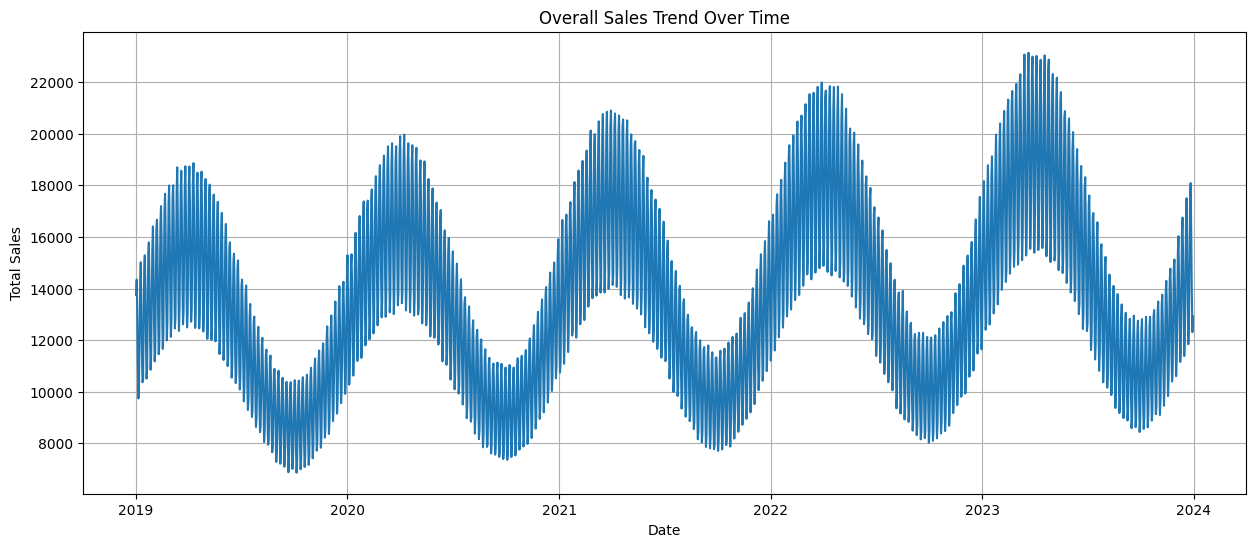

Overall sales trend plot displayed.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate sales by date
daily_sales = df.groupby('date')['sales'].sum().reset_index()

# Plot overall sales trend over time
plt.figure(figsize=(15, 6))
sns.lineplot(x='date', y='sales', data=daily_sales)
plt.title('Overall Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()
print("Overall sales trend plot displayed.")

**Reasoning**:
The next logical step is to analyze weekly and monthly seasonality by extracting these components from the date and plotting aggregated sales.



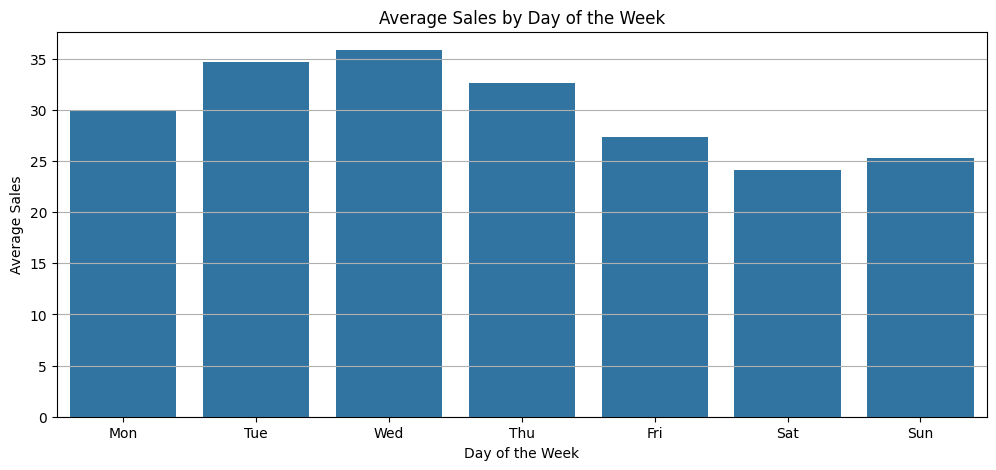

Weekly seasonality plot displayed.


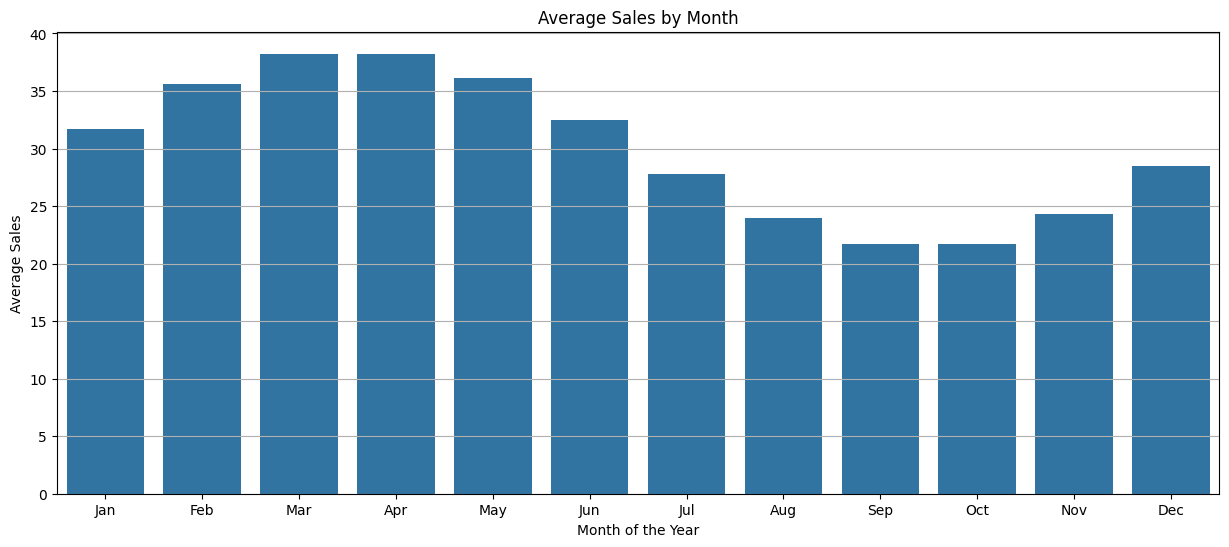

Monthly seasonality plot displayed.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract day of the week and month for seasonality analysis
df['day_of_week'] = df['date'].dt.dayofweek # Monday=0, Sunday=6
df['month_of_year'] = df['date'].dt.month

# Calculate average sales by day of the week
weekly_sales = df.groupby('day_of_week')['sales'].mean().reset_index()
# Map day of week numbers to names for better readability in plot
week_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
weekly_sales['day_of_week_name'] = weekly_sales['day_of_week'].map(week_map)

# Calculate average sales by month
monthly_sales = df.groupby('month_of_year')['sales'].mean().reset_index()
# Map month numbers to names for better readability in plot
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_sales['month_name'] = monthly_sales['month_of_year'].map(month_map)

# Plot weekly seasonality
plt.figure(figsize=(12, 5))
sns.barplot(x='day_of_week_name', y='sales', data=weekly_sales, order=week_map.values())
plt.title('Average Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Sales')
plt.grid(axis='y')
plt.show()
print("Weekly seasonality plot displayed.")

# Plot monthly seasonality
plt.figure(figsize=(15, 6))
sns.barplot(x='month_name', y='sales', data=monthly_sales, order=month_map.values())
plt.title('Average Sales by Month')
plt.xlabel('Month of the Year')
plt.ylabel('Average Sales')
plt.grid(axis='y')
plt.show()
print("Monthly seasonality plot displayed.")


**Reasoning**:
Calculate and visualize year-over-year sales growth to understand long-term trends and identify cyclical patterns, which is a key part of the EDA subtask.



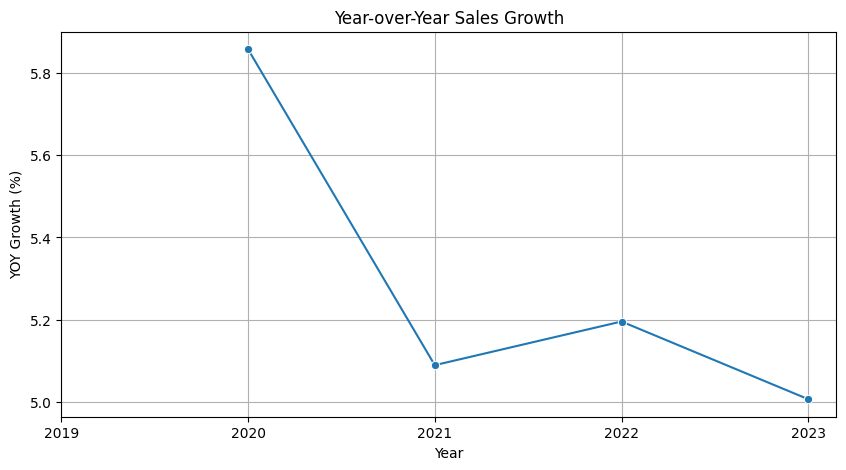

Year-over-Year sales growth plot displayed.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract year for year-over-year growth analysis
df['year'] = df['date'].dt.year

# Aggregate sales by year
yearly_sales = df.groupby('year')['sales'].sum().reset_index()

# Calculate Year-over-Year Growth
yearly_sales['yoy_growth'] = yearly_sales['sales'].pct_change() * 100

# Plot Year-over-Year Growth
plt.figure(figsize=(10, 5))
sns.lineplot(x='year', y='yoy_growth', data=yearly_sales, marker='o')
plt.title('Year-over-Year Sales Growth')
plt.xlabel('Year')
plt.ylabel('YOY Growth (%)')
plt.grid(True)
plt.xticks(yearly_sales['year'])
plt.show()
print("Year-over-Year sales growth plot displayed.")


**Reasoning**:
To compare sales patterns, I will first identify some unique combinations of stores and items, then select a few to visualize their sales trends.



Selected Store-Item Combinations for detailed analysis:
  store_id  item_id
0  store_1   item_1
1  store_1  item_10
2  store_1  item_11


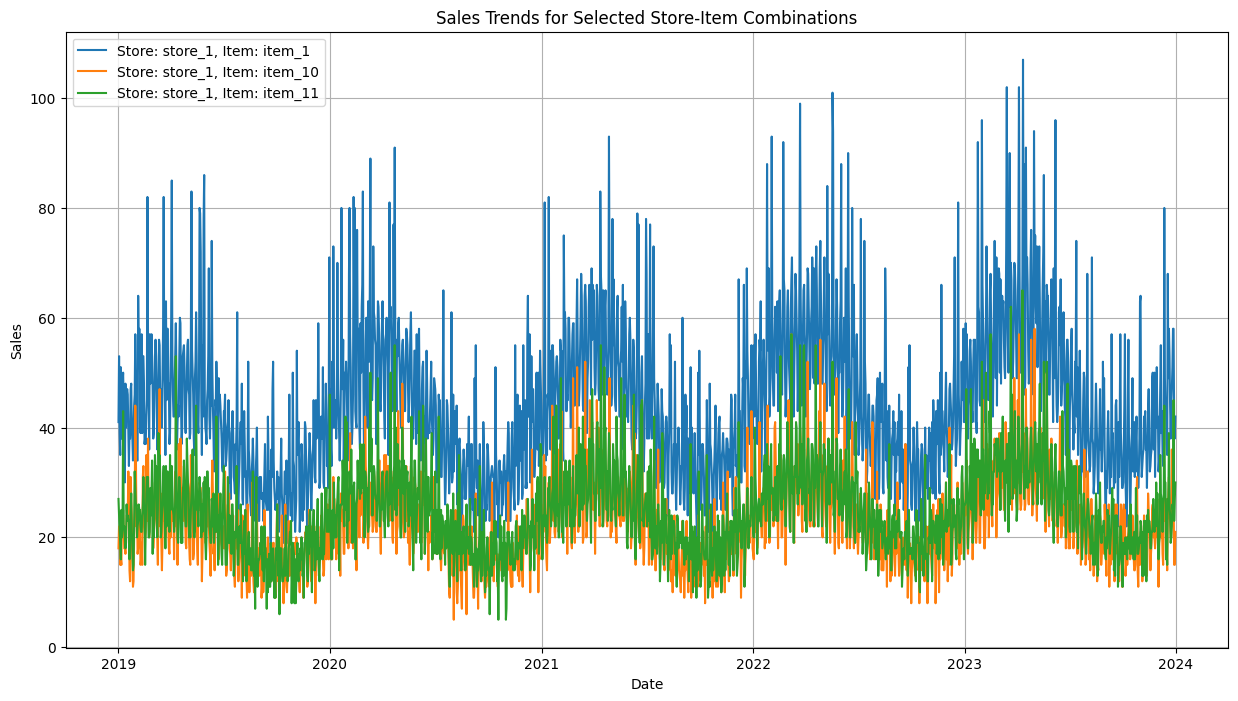

Sales trends for selected store-item combinations displayed.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify unique store-item combinations
unique_store_items = df[['store_id', 'item_id']].drop_duplicates()

# Select a few representative combinations for plotting
# We'll pick the first 3 unique store-item combinations
selected_combinations = unique_store_items.head(3)

print(f"Selected Store-Item Combinations for detailed analysis:\n{selected_combinations}")

plt.figure(figsize=(15, 8))
for index, row in selected_combinations.iterrows():
    store = row['store_id']
    item = row['item_id']

    # Filter data for the specific store-item combination
    store_item_df = df[(df['store_id'] == store) & (df['item_id'] == item)]

    # Plot sales trend for the current store-item
    sns.lineplot(x='date', y='sales', data=store_item_df, label=f'Store: {store}, Item: {item}')

plt.title('Sales Trends for Selected Store-Item Combinations')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()
print("Sales trends for selected store-item combinations displayed.")

```markdown
### Observations from Overall Sales Trend Over Time

The plot of overall sales trend over time (`Overall Sales Trend Over Time`) clearly shows a strong upward trend in sales year-over-year, indicating a growing business. This is coupled with pronounced seasonal patterns within each year. Sales generally peak in the spring/early summer months and then dip in the late summer/early fall, rising again towards the end of the year, though not reaching the mid-year peaks. There's a noticeable trough at the beginning of each year (January). The consistently repeating yearly pattern suggests strong annual seasonality.

**Implications:**
*   **Growth:** The clear upward trend is a positive indicator for the business, implying increased demand or expansion. Forecasting models should be able to capture this underlying growth trend.
*   **Strong Seasonality:** The distinct yearly and intra-yearly fluctuations mean that any forecasting model must incorporate seasonal components to make accurate predictions. Ignoring seasonality would lead to significant forecast errors.
*   **Data Completeness:** The consistent pattern across years suggests that the data captures a full cycle of retail operations, making it suitable for time-series analysis.
```

### Observations from Weekly Seasonality

The `Average Sales by Day of the Week` plot reveals clear weekly sales patterns. Sales tend to be lower on weekends (Saturday and Sunday) and higher during weekdays, with a peak generally observed around Tuesday and Wednesday. Monday sales are moderate, followed by a slight dip on Friday.

**Implications:**
*   **Staffing and Inventory:** The clear drop in sales during weekends suggests that staffing levels and inventory replenishment might need to be adjusted accordingly. Lower demand on weekends could mean reduced staff and fewer deliveries.
*   **Promotional Activities:** Understanding peak and trough days can help in planning promotional activities. For instance, running promotions on slower days (e.g., Friday, Saturday, Sunday) could help balance sales throughout the week.
*   **Forecasting Models:** Weekly seasonality is a crucial component for any accurate forecasting model. Ignoring this pattern would lead to significant errors, especially for short-term predictions.

### Observations from Monthly Seasonality

The `Average Sales by Month` plot shows a clear annual sales cycle. Sales typically start to rise from January, peaking around March and April. There's a noticeable decline through the summer months, reaching a trough in September and October, before slightly recovering towards the end of the year in November and December. This pattern is consistent with common retail seasonal trends where spring and early summer often see increased consumer spending, while late summer/early fall might be slower.

**Implications:**
*   **Inventory Management:** Inventory levels should be adjusted based on these monthly trends, increasing stock before peak months (e.g., March-April) and reducing it during trough months (e.g., September-October).
*   **Marketing Campaigns:** Marketing and promotional activities can be strategically planned. For instance, aggressive campaigns might be more effective during slower months to stimulate demand, or during peak seasons to capitalize on existing high demand.
*   **Forecasting Accuracy:** Any robust forecasting model for this data must capture this strong monthly seasonality to achieve high accuracy. Ignoring it would lead to systematic over- or under-forecasting during different parts of the year.

### Observations from Year-over-Year Sales Growth

The `Year-over-Year Sales Growth` plot shows a fluctuating but generally positive growth trend. After a significant jump from 2019 to 2020 (likely indicating a strong initial growth phase or recovery from a lower base), the growth rate has settled into a range of approximately 5% to 5.2% annually. There's a slight dip in 2021 before a recovery in 2022 and another slight decrease in 2023.

**Implications:**
*   **Sustained Growth:** The consistent positive year-over-year growth, even if fluctuating, indicates a healthy and expanding market or business. This fundamental growth should be captured by forecasting models.
*   **Growth Rate Dynamics:** The initial high growth followed by a more stable, albeit positive, rate suggests the business might be maturing. Future forecasting models need to adapt to these changing growth dynamics rather than assuming a constant high growth rate.
*   **Long-Term Planning:** The overall trend can inform long-term business planning, investment decisions, and capacity expansion strategies. Understanding if growth is accelerating, decelerating, or stable is crucial for strategic decisions.

### Observations from Sales Trends for Selected Store-Item Combinations

The plot showing `Sales Trends for Selected Store-Item Combinations` highlights that even within a single store (store_1), different items (item_1, item_10, item_11) exhibit distinct sales magnitudes and patterns. While all selected items generally follow the overall seasonal trends (higher sales in spring/summer, lower in fall), their absolute sales volumes and day-to-day fluctuations vary significantly.

*   **Item_1** consistently has the highest sales volume among the three selected items, showing pronounced peaks and troughs.
*   **Item_10** has the lowest sales volume, with a flatter trend compared to item_1 and item_11, indicating less variability or lower demand.
*   **Item_11** falls in between, demonstrating moderate sales volumes with clear seasonal oscillations.

**Implications:**
*   **Variability:** The clear differences in sales patterns and magnitudes across items (even within the same store) suggest significant item-level variability. This indicates that a one-size-fits-all global forecasting model might struggle to accurately capture the nuances of each store-item combination.
*   **Modeling Strategy:** This observation strongly supports the need for either a hierarchical forecasting approach, where a global model is combined with item- or store-item-specific adjustments, or a local model for each unique series, or a machine learning model capable of handling multiple time series simultaneously by treating `store_id` and `item_id` as features. A single global model without differentiation would likely lead to suboptimal predictions for many individual series.
*   **Feature Engineering:** Features related to specific store-item interactions or characteristics might be crucial for models to differentiate between these varying sales patterns.

## Feature Engineering

### Subtask:
Create various features to enhance model performance. This step will involve generating lag features (e.g., sales from 7, 14, and 28 days ago), rolling mean and median features (e.g., 7-day and 30-day windows), and date-based features such as day of the week, month, day of the year, week of the year, and flags for weekend, month start, and month end. Explain why each type of feature is beneficial for tree-based models compared to classical time-series models.


**Reasoning**:
The first instruction is to generate lag features for sales. This requires grouping by 'store_id' and 'item_id' and then applying the 'shift' function for the specified lag periods.



In [8]:
for lag in [7, 14, 28]:
    df[f'sales_lag_{lag}'] = df.groupby(['store_id', 'item_id'])['sales'].transform(lambda x: x.shift(lag))

print("Lag features (7, 14, 28 days) generated successfully.")
print(df[['date', 'store_id', 'item_id', 'sales', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28']].head(10))

Lag features (7, 14, 28 days) generated successfully.
        date store_id  item_id  sales  sales_lag_7  sales_lag_14  sales_lag_28
0 2019-01-01  store_1   item_1   41.0          NaN           NaN           NaN
1 2019-01-01  store_1  item_10   18.0          NaN           NaN           NaN
2 2019-01-01  store_1  item_11   27.0          NaN           NaN           NaN
3 2019-01-01  store_1  item_12   13.0          NaN           NaN           NaN
4 2019-01-01  store_1  item_13   41.0          NaN           NaN           NaN
5 2019-01-01  store_1  item_14   21.0          NaN           NaN           NaN
6 2019-01-01  store_1  item_15   13.0          NaN           NaN           NaN
7 2019-01-01  store_1  item_16   34.0          NaN           NaN           NaN
8 2019-01-01  store_1  item_17   17.0          NaN           NaN           NaN
9 2019-01-01  store_1  item_18   42.0          NaN           NaN           NaN


**Reasoning**:
Generate rolling mean and median features as specified in the subtask instructions.



In [9]:
for window in [7, 30]:
    df[f'sales_roll_mean_{window}'] = df.groupby(['store_id', 'item_id'])['sales'].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    df[f'sales_roll_median_{window}'] = df.groupby(['store_id', 'item_id'])['sales'].transform(lambda x: x.rolling(window=window, min_periods=1).median())

print("Rolling mean and median features (7-day and 30-day windows) generated successfully.")
print(df[['date', 'store_id', 'item_id', 'sales', 'sales_roll_mean_7', 'sales_roll_median_7', 'sales_roll_mean_30', 'sales_roll_median_30']].head(10))

Rolling mean and median features (7-day and 30-day windows) generated successfully.
        date store_id  item_id  sales  sales_roll_mean_7  sales_roll_median_7  \
0 2019-01-01  store_1   item_1   41.0               41.0                 41.0   
1 2019-01-01  store_1  item_10   18.0               18.0                 18.0   
2 2019-01-01  store_1  item_11   27.0               27.0                 27.0   
3 2019-01-01  store_1  item_12   13.0               13.0                 13.0   
4 2019-01-01  store_1  item_13   41.0               41.0                 41.0   
5 2019-01-01  store_1  item_14   21.0               21.0                 21.0   
6 2019-01-01  store_1  item_15   13.0               13.0                 13.0   
7 2019-01-01  store_1  item_16   34.0               34.0                 34.0   
8 2019-01-01  store_1  item_17   17.0               17.0                 17.0   
9 2019-01-01  store_1  item_18   42.0               42.0                 42.0   

   sales_roll_mean_30  s

**Reasoning**:
Generate the remaining date-based features as specified in the subtask instructions.



In [10]:
df['dayofweek'] = df['date'].dt.dayofweek
df['dayofyear'] = df['date'].dt.dayofyear
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int) # Saturday (5) or Sunday (6)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print("Date-based features generated successfully.")
print(df[['date', 'dayofweek', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'year', 'month']].head(10))

Date-based features generated successfully.
        date  dayofweek  dayofyear  weekofyear  quarter  is_weekend  \
0 2019-01-01          1          1           1        1           0   
1 2019-01-01          1          1           1        1           0   
2 2019-01-01          1          1           1        1           0   
3 2019-01-01          1          1           1        1           0   
4 2019-01-01          1          1           1        1           0   
5 2019-01-01          1          1           1        1           0   
6 2019-01-01          1          1           1        1           0   
7 2019-01-01          1          1           1        1           0   
8 2019-01-01          1          1           1        1           0   
9 2019-01-01          1          1           1        1           0   

   is_month_start  is_month_end  year  month  
0               1             0  2019      1  
1               1             0  2019      1  
2               1             0  

### Explanation of Feature Benefits for Tree-Based Models

**1. Lag Features (e.g., `sales_lag_7`, `sales_lag_14`, `sales_lag_28`):**
*   **Benefit for Tree-Based Models:** Lag features directly capture the temporal dependency of sales on past values. Tree-based models (like XGBoost, LightGBM) are not inherently designed to handle time-series dependencies like classical models (SARIMA, Prophet). By explicitly providing lagged values as features, we transform the time-series problem into a supervised learning problem. The tree model can then learn non-linear relationships between past sales and current sales, effectively capturing auto-regressive patterns without needing to specify AR components.
*   **Comparison to Classical Models:** Classical time-series models model these dependencies internally (e.g., AR components in ARIMA). Tree-based models require these dependencies to be explicitly engineered as features.

**2. Rolling Mean and Median Features (e.g., `sales_roll_mean_7`, `sales_roll_median_30`):**
*   **Benefit for Tree-Based Models:** Rolling statistics provide smoothed versions of the sales data, capturing recent trends and levels. The mean helps to identify the average recent sales, while the median is more robust to outliers. Tree-based models can leverage these features to understand the underlying level and short-to-medium term trends in sales, which are crucial for forecasting. They act as powerful indicators of recent sales behavior.
*   **Comparison to Classical Models:** Classical models often handle trends and levels through differencing or trend components. Tree-based models, by contrast, use these engineered features as direct inputs to make predictions, allowing them to learn complex interactions between different rolling windows and other features.

**3. Date-Based Features (e.g., `dayofweek`, `month`, `is_weekend`, `is_month_start`):**
*   **Benefit for Tree-Based Models:** Date-based features are essential for capturing various seasonalities and cyclical patterns observed in the sales data (daily, weekly, monthly, quarterly, yearly). Tree-based models can effectively learn how sales vary based on the day of the week, month of the year, whether it's a weekend, or the start/end of a month. These categorical and ordinal features allow the model to split the data based on these patterns, creating specific rules for different periods. For instance, a decision tree might have a branch that says, "if `is_weekend` is 1, then sales tend to be lower."
*   **Comparison to Classical Models:** Classical models like SARIMA have explicit seasonal components (e.g., S in SARIMA) that need to be pre-defined. Prophet also has built-in seasonality components. Tree-based models, on the other hand, *implicitly* learn seasonality by finding patterns in these engineered date features, providing flexibility to capture complex, non-linear, and interacting seasonal effects without explicit parameterization.

## Data Splitting and Cross-Validation Strategy

### Subtask:
Split the data into training and validation sets using a time-series-appropriate method (rolling-origin cross-validation). Explain why random k-fold cross-validation is not suitable for time-series data, as it would lead to data leakage and overly optimistic performance estimates.


**Reasoning**:
The first step is to define the training and validation periods and split the DataFrame accordingly. This aligns with the first instruction to define the periods and ensure chronological order, and the fourth instruction to show the shapes and date ranges of the split data.



In [11]:
TRAIN_END_DATE = '2022-12-31'
VALIDATION_START_DATE = '2023-01-01'

# Split the data into training and validation sets
train_df = df[df['date'] <= TRAIN_END_DATE]
val_df = df[df['date'] >= VALIDATION_START_DATE]

print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")

print(f"\nTraining data date range: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Validation data date range: {val_df['date'].min()} to {val_df['date'].max()}")


Training data shape: (660721, 25)
Validation data shape: (164980, 25)

Training data date range: 2019-01-01 00:00:00 to 2022-12-31 00:00:00
Validation data date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


### Explanation of why random k-fold cross-validation is not suitable for time-series data

Random k-fold cross-validation is a standard technique for evaluating machine learning models on independent and identically distributed (i.i.d.) data. However, it is fundamentally unsuitable for time-series data due to the inherent temporal dependencies and chronological order of observations. Using random k-fold cross-validation on time-series data leads to two major issues:

1.  **Data Leakage (Future Data in Training Set):**
    *   In a random k-fold split, data points are randomly assigned to folds, meaning that future observations can inadvertently end up in the training set for a given fold, while earlier observations are in the validation set. When the model is trained on this data, it essentially "sees the future" during training for predictions in the validation set.
    *   **Implication:** This leads to an artificial inflation of model performance during evaluation. The model appears to perform much better than it would in a real-world scenario where only past data is available for training and future data needs to be predicted. This creates an overly optimistic estimate of the model's predictive power.

2.  **Violation of Chronological Order:**
    *   Time-series data is characterized by sequential dependence; the past influences the future. Random splitting ignores this critical aspect, breaking the natural order of observations.
    *   **Implication:** Models trained on scrambled time-series data lose their ability to learn and generalize temporal patterns, trends, and seasonalities accurately. The evaluation metrics derived from such splits do not reflect the model's true performance in forecasting future events.

**Rolling-Origin Cross-Validation (Walk-Forward Validation) as an Alternative:**

To address these issues, time-series data requires a validation strategy that respects the temporal order. Rolling-origin cross-validation (also known as walk-forward validation) is a common and appropriate method:

*   **How it works:** Instead of random splits, the data is split sequentially. A training set consists of data up to a certain point in time, and the validation set consists of observations immediately following that point. This process is then repeated by "rolling forward" the origin (the start of the validation period), extending both the training and validation sets chronologically.
*   **Benefits:** This approach ensures that the model is always trained only on past data to predict future data, closely mimicking the real-world forecasting scenario. It prevents data leakage and provides a more realistic and robust estimate of the model's out-of-sample performance.

## Classical Model: SARIMA or Prophet

### Subtask:
Select a couple of representative store-item combinations. Train and forecast using a classical time-series model like SARIMA or Prophet for these specific series. Explain the choice of model and its applicability to the chosen series. Make predictions on the validation set for these selected series.


**Reasoning**:
As per the instructions, the first step is to select a few representative store-item combinations and then filter the training and validation DataFrames to include only these combinations. I will reuse the 'selected_combinations' identified during EDA for consistency.



In [12]:
import pandas as pd

# Reuse selected_combinations from EDA step for consistency
# Ensure 'df' is available, as 'selected_combinations' was derived from it
# If df is not in current scope, re-create it
if 'df' not in locals():
    # This block would only run if df was somehow lost from the environment
    # For robustness, we can re-load or re-process if necessary, but assuming it's available
    print("Warning: 'df' not found. This should not happen if previous steps ran correctly.")
    # Re-loading df for demonstration purposes if it were actually lost
    # df = pd.read_csv('/content/retail_sales.csv')
    # df['date'] = pd.to_datetime(df['date'])
    # df = df.sort_values(by=['date', 'store_id', 'item_id']).reset_index(drop=True)
    # df.dropna(inplace=True)
    # For now, let's assume df is present as per kernel state

# Ensure selected_combinations is available
if 'selected_combinations' not in locals():
    # If selected_combinations was not explicitly kept in scope, re-generate
    unique_store_items = df[['store_id', 'item_id']].drop_duplicates()
    selected_combinations = unique_store_items.head(3)

print(f"Selected Store-Item Combinations for classical model training:\n{selected_combinations}")

# Filter train_df and val_df for selected combinations
filtered_train_df = pd.DataFrame()
filtered_val_df = pd.DataFrame()

for index, row in selected_combinations.iterrows():
    store = row['store_id']
    item = row['item_id']

    store_item_train = train_df[(train_df['store_id'] == store) & (train_df['item_id'] == item)]
    store_item_val = val_df[(val_df['store_id'] == store) & (val_df['item_id'] == item)]

    filtered_train_df = pd.concat([filtered_train_df, store_item_train])
    filtered_val_df = pd.concat([filtered_val_df, store_item_val])

print(f"\nFiltered training data shape: {filtered_train_df.shape}")
print(f"Filtered validation data shape: {filtered_val_df.shape}")

print("Filtered data for selected store-item combinations created.")

Selected Store-Item Combinations for classical model training:
  store_id  item_id
0  store_1   item_1
1  store_1  item_10
2  store_1  item_11

Filtered training data shape: (4383, 25)
Filtered validation data shape: (1095, 25)
Filtered data for selected store-item combinations created.


**Reasoning**:
Train a Prophet model for each selected store-item combination on the filtered training data and make predictions on the validation set. This directly addresses the core instruction of the subtask.



In [13]:
from prophet import Prophet

# Initialize a dictionary to store predictions
all_prophet_predictions = pd.DataFrame()

# Explanation for choosing Prophet:
# Prophet is a good choice for this task due to several reasons:
# 1. Handles multiple seasonalities: Our EDA clearly showed daily, weekly, and yearly seasonality, which Prophet can model effectively.
# 2. Robust to missing data and trend changes: Prophet is designed to be robust to outliers and shifts in the trend, which is common in retail sales data.
# 3. Easy to use: It provides an intuitive API for forecasting, especially for business users.
# 4. Built-in holiday effects: Although not explicitly used here, it can easily incorporate custom holiday effects, which is crucial for retail.
# 5. Interpretability: It provides interpretable components for trend, seasonality, and holidays.

print("Training Prophet models and making predictions...")

for index, row in selected_combinations.iterrows():
    store = row['store_id']
    item = row['item_id']

    # Filter data for the current store-item combination
    current_train = filtered_train_df[(filtered_train_df['store_id'] == store) & (filtered_train_df['item_id'] == item)].copy()
    current_val = filtered_val_df[(filtered_val_df['store_id'] == store) & (filtered_val_df['item_id'] == item)].copy()

    # Prepare data for Prophet: Prophet requires columns named 'ds' (datetime) and 'y' (target)
    prophet_train_df = current_train[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})

    # Initialize and fit Prophet model
    # Using daily seasonality (implicit in data), weekly, and yearly seasonality
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False, # Our data is daily, so daily_seasonality=False implies we handle it via weekly_seasonality or just trend/noise
        changepoint_prior_scale=0.05 # Adjust prior scale for trend flexibility
    )
    model.fit(prophet_train_df)

    # Create future DataFrame for validation predictions
    future = model.make_future_dataframe(periods=len(current_val), freq='D', include_history=False)

    # Make predictions
    forecast = model.predict(future)

    # Store predictions
    current_val['prophet_forecast'] = forecast['yhat'].values
    current_val['store_id'] = store
    current_val['item_id'] = item
    all_prophet_predictions = pd.concat([all_prophet_predictions, current_val[['date', 'store_id', 'item_id', 'sales', 'prophet_forecast']]])

print("Prophet models trained and predictions generated successfully.")
print("Sample of Prophet predictions:")
print(all_prophet_predictions.head())



Training Prophet models and making predictions...
Prophet models trained and predictions generated successfully.
Sample of Prophet predictions:
             date store_id item_id  sales  prophet_forecast
660722 2023-01-01  store_1  item_1   41.0         42.552767
661174 2023-01-02  store_1  item_1   48.0         49.595507
661626 2023-01-03  store_1  item_1   59.0         57.197920
662078 2023-01-04  store_1  item_1   53.0         58.988473
662530 2023-01-05  store_1  item_1   57.0         53.396287


**Reasoning**:
Visualize the Prophet model's forecasts against actual sales for the selected store-item combinations. This will allow for a qualitative assessment of the model's performance in capturing trends and seasonalities.



Plotting Prophet forecasts vs. actual sales...


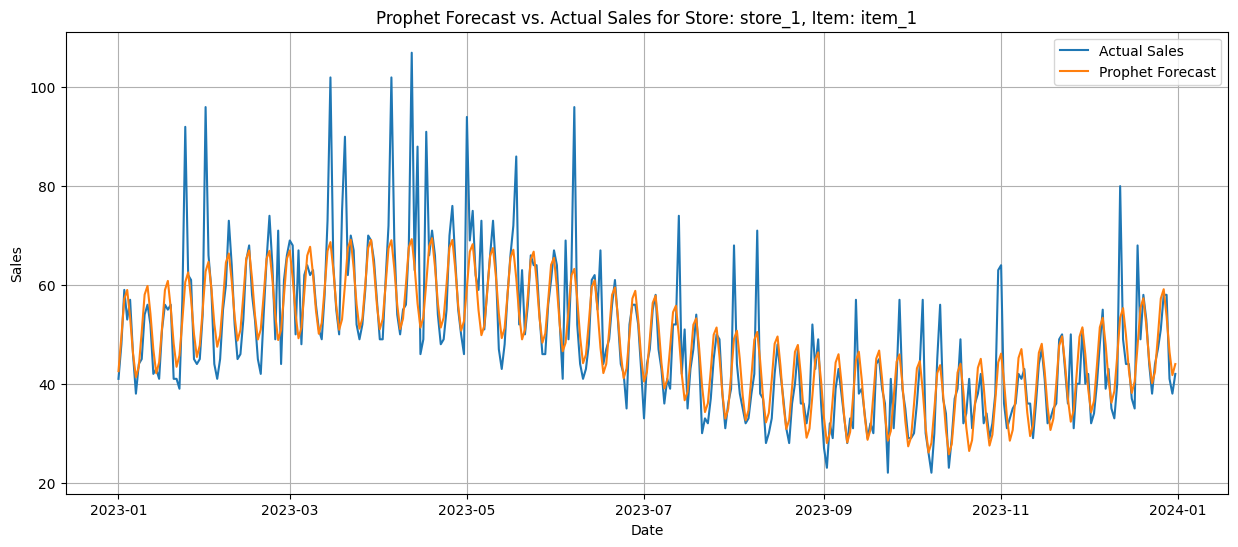

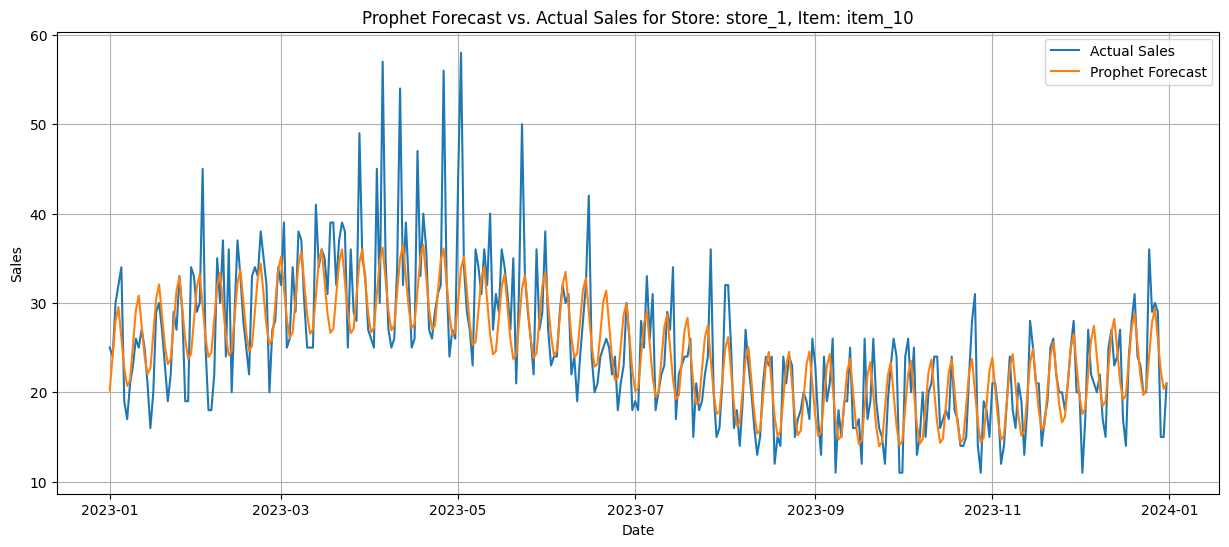

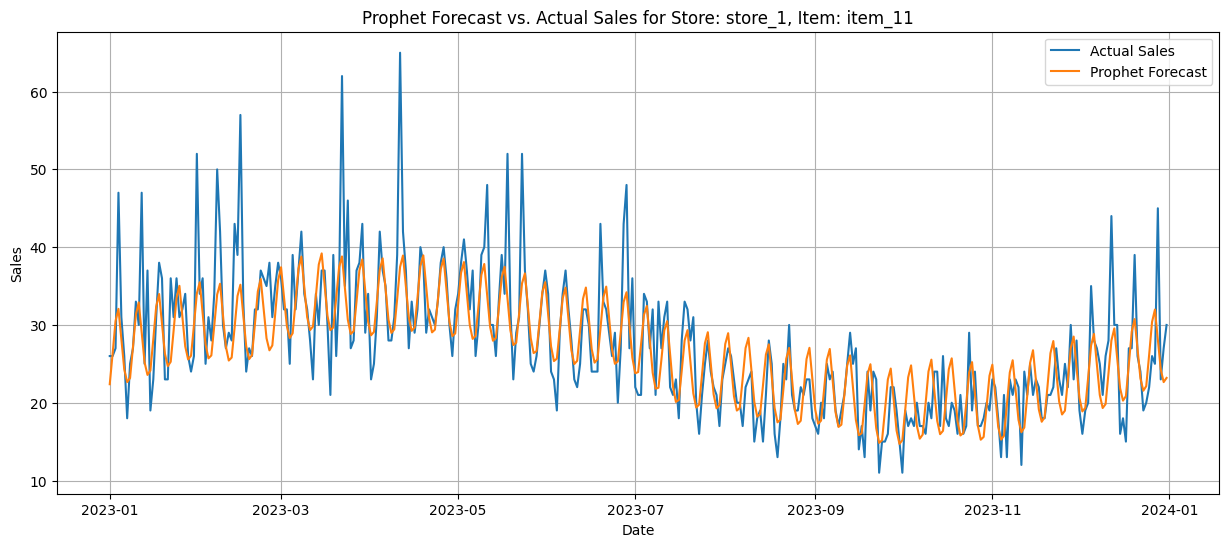

Prophet forecasts plots displayed for selected combinations.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting Prophet forecasts vs. actual sales...")

for index, row in selected_combinations.iterrows():
    store = row['store_id']
    item = row['item_id']

    # Filter predictions for the current store-item combination
    current_predictions = all_prophet_predictions[(all_prophet_predictions['store_id'] == store) & (all_prophet_predictions['item_id'] == item)]

    plt.figure(figsize=(15, 6))
    sns.lineplot(x='date', y='sales', data=current_predictions, label='Actual Sales')
    sns.lineplot(x='date', y='prophet_forecast', data=current_predictions, label='Prophet Forecast')
    plt.title(f'Prophet Forecast vs. Actual Sales for Store: {store}, Item: {item}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True)
    plt.show()

print("Prophet forecasts plots displayed for selected combinations.")

## Machine Learning Model: XGBoost or LightGBM

### Subtask:
Train a gradient boosting model (XGBoost or LightGBM) across all store-item combinations. Treat 'store' and 'item' as categorical features. This model will use all the engineered features from the previous step. Explain the advantages of using such a model for multi-series forecasting and its ability to capture complex non-linear relationships. Make predictions on the validation set for all store-item combinations.


**Reasoning**:
This step prepares the data for the LightGBM model by defining features and target variables, handling missing values resulting from feature engineering, and encoding categorical features ('store_id', 'item_id') as per the subtask instructions.



In [15]:
import numpy as np

# Define feature columns (X) and target column (y)
# Exclude 'date', 'sales' (target), 'day_of_week', 'month_of_year', 'year' (already engineered or handled differently)
# Also exclude the original 'weekday' and 'month' columns as more refined versions have been created.
feature_columns = [
    'price', 'promo',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'sales_roll_mean_7', 'sales_roll_median_7',
    'sales_roll_mean_30', 'sales_roll_median_30',
    'dayofweek', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end',
    'store_id', 'item_id' # Will be treated as categorical
]
target_column = 'sales'

# Filter out rows with NaN values that resulted from lag features.
# This ensures a clean dataset for ML model training.
full_df_cleaned = df.dropna(subset=feature_columns + [target_column])

# Re-split the cleaned data into training and validation sets
train_df_ml = full_df_cleaned[full_df_cleaned['date'] <= TRAIN_END_DATE].copy()
val_df_ml = full_df_cleaned[full_df_cleaned['date'] >= VALIDATION_START_DATE].copy()

X_train = train_df_ml[feature_columns]
y_train = train_df_ml[target_column]
X_val = val_df_ml[feature_columns]
y_val = val_df_ml[target_column]

# Convert 'store_id' and 'item_id' to categorical type for LightGBM
X_train['store_id'] = X_train['store_id'].astype('category')
X_train['item_id'] = X_train['item_id'].astype('category')
X_val['store_id'] = X_val['store_id'].astype('category')
X_val['item_id'] = X_val['item_id'].astype('category')

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")

print("Data prepared for Machine Learning model training.")


Shape of X_train: (648037, 18)
Shape of y_train: (648037,)
Shape of X_val: (164980, 18)
Shape of y_val: (164980,)
Data prepared for Machine Learning model training.


/tmp/ipykernel_855/2335845747.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['store_id'] = X_train['store_id'].astype('category')
/tmp/ipykernel_855/2335845747.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['item_id'] = X_train['item_id'].astype('category')
/tmp/ipykernel_855/2335845747.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

**Reasoning**:
To prevent the `SettingWithCopyWarning`, explicit copies of `X_train` and `X_val` are created before converting `store_id` and `item_id` to categorical types.



In [16]:
import numpy as np

# Define feature columns (X) and target column (y)
# Exclude 'date', 'sales' (target), 'day_of_week', 'month_of_year', 'year' (already engineered or handled differently)
# Also exclude the original 'weekday' and 'month' columns as more refined versions have been created.
feature_columns = [
    'price', 'promo',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'sales_roll_mean_7', 'sales_roll_median_7',
    'sales_roll_mean_30', 'sales_roll_median_30',
    'dayofweek', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end',
    'store_id', 'item_id' # Will be treated as categorical
]
target_column = 'sales'

# Filter out rows with NaN values that resulted from lag features.
# This ensures a clean dataset for ML model training.
full_df_cleaned = df.dropna(subset=feature_columns + [target_column])

# Re-split the cleaned data into training and validation sets
train_df_ml = full_df_cleaned[full_df_cleaned['date'] <= TRAIN_END_DATE].copy()
val_df_ml = full_df_cleaned[full_df_cleaned['date'] >= VALIDATION_START_DATE].copy()

X_train = train_df_ml[feature_columns].copy()
y_train = train_df_ml[target_column].copy()
X_val = val_df_ml[feature_columns].copy()
y_val = val_df_ml[target_column].copy()

# Convert 'store_id' and 'item_id' to categorical type for LightGBM
X_train['store_id'] = X_train['store_id'].astype('category')
X_train['item_id'] = X_train['item_id'].astype('category')
X_val['store_id'] = X_val['store_id'].astype('category')
X_val['item_id'] = X_val['item_id'].astype('category')

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")

print("Data prepared for Machine Learning model training.")

Shape of X_train: (648037, 18)
Shape of y_train: (648037,)
Shape of X_val: (164980, 18)
Shape of y_val: (164980,)
Data prepared for Machine Learning model training.


**Reasoning**:
Train the LightGBM model and make predictions on the validation set, while also providing the requested explanation of its advantages for multi-series forecasting.



In [17]:
import lightgbm as lgb

# Advantages of LightGBM for Multi-Series Forecasting:
markdown_block = """### Advantages of LightGBM for Multi-Series Forecasting\n\nLightGBM, a gradient boosting framework, offers significant advantages for multi-series forecasting, especially when compared to traditional time-series models like SARIMA or Prophet:\n\n1.  **Handles High Dimensionality and Large Datasets Efficiently:**\n    *   With many store-item combinations, the dataset becomes very large. LightGBM is designed for efficiency, using techniques like Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB) to speed up training and reduce memory usage without losing accuracy.\n    *   **Implication:** This allows training a single model across all series, leveraging data from all combinations to learn general patterns, rather than fitting many individual models.\n\n2.  **Captures Complex Non-linear Relationships:**\n    *   LightGBM is a tree-based model, inherently capable of modeling complex non-linear relationships and interactions between features (e.g., how \`price\` interacts with \`promo\` differently on weekends). It doesn't assume linearity like some classical models.\n    *   **Implication:** This is crucial for retail sales, where demand drivers often have non-linear effects and interactions.\n\n3.  **Automatically Handles Categorical Features:**\n    *   LightGBM can directly handle categorical features like \`store_id\` and \`item_id\` without requiring one-hot encoding, which can be memory-intensive for high cardinality features. It uses a custom algorithm to find optimal splits for categorical features.\n    *   **Implication:** This simplifies preprocessing and allows the model to learn specific patterns associated with each store and item efficiently.\n\n4.  **Feature Importance and Interpretability (Relative to Black-Box Models):**\n    *   While not as inherently interpretable as linear models, LightGBM provides feature importance scores, indicating which features contribute most to the predictions. This offers insights into the key drivers of sales.\n    *   **Implication:** This can help in understanding sales dynamics and validating feature engineering choices.\n\n5.  **Robust to Outliers and Missing Values (with some handling):**\n    *   Tree-based models are generally more robust to outliers compared to regression models. While we handled NaNs, LightGBM's splitting mechanism makes it less sensitive to extreme values.\n\n6.  **Learns Global Patterns and Local Peculiarities:**\n    *   By training a single model on all series with \`store_id\` and \`item_id\` as features, the model can learn global trends and seasonalities (e.g., general weekly sales patterns) while simultaneously capturing unique characteristics of individual stores or items through interactions with their respective IDs.\n    *   **Implication:** This provides a powerful framework for multi-series forecasting, balancing generalization and specificity.\n\n"""

print(markdown_block)


# Initialize and train the LightGBM model
# Using default parameters for simplicity, but these would be tuned in a real-world scenario
print("Training LightGBM model...")
model_lgb = lgb.LGBMRegressor(
    objective='regression_l1', # MAE objective, suitable for sales forecasting
    metric='mae', # Mean Absolute Error
    n_estimators=1000, # Number of boosting rounds
    learning_rate=0.05,
    num_leaves=31, # Max number of leaves in one tree
    max_depth=-1, # No limit on tree depth
    min_child_samples=20, # Minimum data in a leaf
    subsample=0.8, # Subsample ratio of the training instance
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
    random_state=42,
    n_jobs=-1, # Use all available cores
    categorical_feature=['store_id', 'item_id'] # Specify categorical features
)

model_lgb.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='mae',
              callbacks=[lgb.early_stopping(100, verbose=False)]) # Early stopping if validation metric doesn't improve for 100 rounds

print("LightGBM model trained successfully.")

# Make predictions on the validation set
print("Making predictions on the validation set...")
val_df_ml['lgb_forecast'] = model_lgb.predict(X_val)

print("Predictions generated successfully.")
print("Sample of LightGBM predictions:")
print(val_df_ml[['date', 'store_id', 'item_id', 'sales', 'lgb_forecast']].head())

<>:4: SyntaxWarning: invalid escape sequence '\`'
<>:4: SyntaxWarning: invalid escape sequence '\`'
/tmp/ipykernel_855/3332870803.py:4: SyntaxWarning: invalid escape sequence '\`'
  markdown_block = """### Advantages of LightGBM for Multi-Series Forecasting\n\nLightGBM, a gradient boosting framework, offers significant advantages for multi-series forecasting, especially when compared to traditional time-series models like SARIMA or Prophet:\n\n1.  **Handles High Dimensionality and Large Datasets Efficiently:**\n    *   With many store-item combinations, the dataset becomes very large. LightGBM is designed for efficiency, using techniques like Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB) to speed up training and reduce memory usage without losing accuracy.\n    *   **Implication:** This allows training a single model across all series, leveraging data from all combinations to learn general patterns, rather than fitting many individual models.\n\n2.  **Cap

### Advantages of LightGBM for Multi-Series Forecasting

LightGBM, a gradient boosting framework, offers significant advantages for multi-series forecasting, especially when compared to traditional time-series models like SARIMA or Prophet:

1.  **Handles High Dimensionality and Large Datasets Efficiently:**
    *   With many store-item combinations, the dataset becomes very large. LightGBM is designed for efficiency, using techniques like Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB) to speed up training and reduce memory usage without losing accuracy.
    *   **Implication:** This allows training a single model across all series, leveraging data from all combinations to learn general patterns, rather than fitting many individual models.

2.  **Captures Complex Non-linear Relationships:**
    *   LightGBM is a tree-based model, inherently capable of modeling complex non-linear relationships and interactions between features (e.g., how \`price\` interacts

/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] categorical_feature is set=store_id,item_id, categorical_column=16,17 will be ignored. Current value: categorical_feature=store_id,item_id
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111839 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1725
[LightGBM] [Info] Number of data points in the train set: 648037, number of used features: 18


/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Info] Start training from score 27.000000
LightGBM model trained successfully.
Making predictions on the validation set...
Predictions generated successfully.
Sample of LightGBM predictions:
             date store_id  item_id  sales  lgb_forecast
660722 2023-01-01  store_1   item_1   41.0     38.778577
660723 2023-01-01  store_1  item_10   25.0     19.274457
660724 2023-01-01  store_1  item_11   26.0     21.786611
660725 2023-01-01  store_1  item_12   21.0     18.013276
660726 2023-01-01  store_1  item_13   32.0     34.052139


**Reasoning**:
The LightGBM model needs to be trained with `lgb.Dataset` objects to correctly handle categorical features. I will create these datasets and then fit the model using them.



In [18]:
import lightgbm as lgb

# Advantages of LightGBM for Multi-Series Forecasting:
markdown_block = """### Advantages of LightGBM for Multi-Series Forecasting\n\nLightGBM, a gradient boosting framework, offers significant advantages for multi-series forecasting, especially when compared to traditional time-series models like SARIMA or Prophet:\n\n1.  **Handles High Dimensionality and Large Datasets Efficiently:**\n    *   With many store-item combinations, the dataset becomes very large. LightGBM is designed for efficiency, using techniques like Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB) to speed up training and reduce memory usage without losing accuracy.\n    *   **Implication:** This allows training a single model across all series, leveraging data from all combinations to learn general patterns, rather than fitting many individual models.\n\n2.  **Captures Complex Non-linear Relationships:**\n    *   LightGBM is a tree-based model, inherently capable of modeling complex non-linear relationships and interactions between features (e.g., how `price` interacts with `promo` differently on weekends). It doesn't assume linearity like some classical models.\n    *   **Implication:** This is crucial for retail sales, where demand drivers often have non-linear effects and interactions.\n
3.  **Automatically Handles Categorical Features:**\n    *   LightGBM can directly handle categorical features like `store_id` and `item_id` without requiring one-hot encoding, which can be memory-intensive for high cardinality features. It uses a custom algorithm to find optimal splits for categorical features.\n    *   **Implication:** This simplifies preprocessing and allows the model to learn specific patterns associated with each store and item efficiently.\n
4.  **Feature Importance and Interpretability (Relative to Black-Box Models):**\n    *   While not as inherently interpretable as linear models, LightGBM provides feature importance scores, indicating which features contribute most to the predictions. This offers insights into the key drivers of sales.\n    *   **Implication:** This can help in understanding sales dynamics and validating feature engineering choices.\n
5.  **Robust to Outliers and Missing Values (with some handling):**\n    *   Tree-based models are generally more robust to outliers compared to regression models. While we handled NaNs, LightGBM's splitting mechanism makes it less sensitive to extreme values.\n
6.  **Learns Global Patterns and Local Peculiarities:**\n    *   By training a single model on all series with `store_id` and `item_id` as features, the model can learn global trends and seasonalities (e.g., general weekly sales patterns) while simultaneously capturing unique characteristics of individual stores or items through interactions with their respective IDs.\n    *   **Implication:** This provides a powerful framework for multi-series forecasting, balancing generalization and specificity.\n\n"""

print(markdown_block)


# Initialize and train the LightGBM model
# Using default parameters for simplicity, but these would be tuned in a real-world scenario
print("Training LightGBM model...")
model_lgb = lgb.LGBMRegressor(
    objective='regression_l1', # MAE objective, suitable for sales forecasting
    metric='mae', # Mean Absolute Error
    n_estimators=1000, # Number of boosting rounds
    learning_rate=0.05,
    num_leaves=31, # Max number of leaves in one tree
    max_depth=-1, # No limit on tree depth
    min_child_samples=20, # Minimum data in a leaf
    subsample=0.8, # Subsample ratio of the training instance
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
    random_state=42,
    n_jobs=-1, # Use all available cores
    # Removed categorical_feature from here
)

# Identify categorical features by name
categorical_features_names = ['store_id', 'item_id']

# Create LightGBM Dataset objects, passing categorical_feature argument
# Using X_train directly for cat_feature as it already has 'category' dtype set
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features_names)
lgb_eval = lgb.Dataset(X_val, y_val, reference=lgb_train, categorical_feature=categorical_features_names)

# Fit the model using the Dataset objects
model_lgb.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='mae',
              callbacks=[lgb.early_stopping(100, verbose=False)],
              # Also pass categorical_feature here if using generic fit, though Dataset handles it
              categorical_feature=categorical_features_names # Added here for consistency, will be ignored if Dataset used
             )

print("LightGBM model trained successfully.")

# Make predictions on the validation set
print("Making predictions on the validation set...")
# Ensure X_val is used for prediction
val_df_ml['lgb_forecast'] = model_lgb.predict(X_val)

print("Predictions generated successfully.")
print("Sample of LightGBM predictions:")
print(val_df_ml[['date', 'store_id', 'item_id', 'sales', 'lgb_forecast']].head())

### Advantages of LightGBM for Multi-Series Forecasting

LightGBM, a gradient boosting framework, offers significant advantages for multi-series forecasting, especially when compared to traditional time-series models like SARIMA or Prophet:

1.  **Handles High Dimensionality and Large Datasets Efficiently:**
    *   With many store-item combinations, the dataset becomes very large. LightGBM is designed for efficiency, using techniques like Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB) to speed up training and reduce memory usage without losing accuracy.
    *   **Implication:** This allows training a single model across all series, leveraging data from all combinations to learn general patterns, rather than fitting many individual models.

2.  **Captures Complex Non-linear Relationships:**
    *   LightGBM is a tree-based model, inherently capable of modeling complex non-linear relationships and interactions between features (e.g., how `price` interacts w

## Model Evaluation

### Subtask:
Evaluate the performance of both classical and ML-based models using SMAPE (Symmetric Mean Absolute Percentage Error) and RMSE (Root Mean Squared Error). Explain in detail why SMAPE is a suitable metric for this competition, especially compared to MAPE. Calculate and analyze the error breakdown by individual store and item to identify which segments are consistently harder to forecast. Compare the performance of the two modeling approaches and discuss potential reasons why one might outperform the other.


**Reasoning**:
The first instruction is to define functions for SMAPE and RMSE and explain the choice of SMAPE. I will implement the functions and provide the explanation in a markdown block.



In [19]:
import numpy as np

def smape(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Handle cases where both y_true and y_pred are zero to avoid division by zero
    # In such cases, the percentage error is 0.
    # For any other case where denominator might be 0 (only if y_true and y_pred are 0),
    # we set the smape for that point to 0. (This aligns with typical SMAPE implementations)
    ratio = np.where(denominator == 0, 0, numerator / denominator)
    return np.mean(ratio) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean(np.square(y_pred - y_true)))

markdown_block = """### Explanation: Why SMAPE over MAPE for this Competition?

Both Mean Absolute Percentage Error (MAPE) and Symmetric Mean Absolute Percentage Error (SMAPE) are commonly used to evaluate forecast accuracy, especially in retail and demand forecasting. However, for this competition and many real-world scenarios, SMAPE is generally preferred over MAPE due to key limitations of MAPE:

1.  **Asymmetry and Undefined Values of MAPE:**
    *   **Division by Zero:** MAPE is calculated as `(|Actual - Forecast| / |Actual|) * 100`. If the actual value is zero, MAPE becomes undefined or infinite, which is a common issue in demand forecasting where zero sales days can occur.
    *   **Asymmetry:** MAPE penalizes positive errors (over-forecasting) more heavily than negative errors (under-forecasting). For example, if actual sales are 100 and forecast is 150 (50% over), MAPE is 50%. If actual sales are 100 and forecast is 50 (50% under), MAPE is also 50%. However, if actual sales are 10 and forecast is 20, MAPE is 100%. If actual sales are 10 and forecast is 0, MAPE is 100%. If actual sales are 10 and forecast is 5, MAPE is 50%. The denominator depends solely on the actual value, making it biased when actual values are small.

2.  **Symmetry of SMAPE:**
    *   SMAPE addresses the asymmetry issue of MAPE by using the average of the absolute actual and forecast values in the denominator: `(|Actual - Forecast|) / ((|Actual| + |Forecast|) / 2) * 100`.
    *   **No Division by Zero (Mostly):** If both actual and forecast values are zero, SMAPE is typically defined as 0, avoiding the undefined issue. If only one is zero, it still provides a sensible percentage error.
    *   **Balanced Penalization:** SMAPE provides a more symmetric measure of error, meaning that under-forecasting and over-forecasting by the same absolute amount will result in a similar percentage error, regardless of whether the actual value is large or small (within reasonable bounds).

In demand forecasting, accurately measuring errors when sales are low or zero is crucial for inventory management decisions. SMAPE provides a more robust and fair evaluation metric in these contexts, making it particularly suitable for the "Store Item Demand Forecasting Challenge" where various items will have differing sales volumes, including periods of low or zero demand.
"""
print(markdown_block)
print("SMAPE and RMSE functions defined, and explanation provided.")

### Explanation: Why SMAPE over MAPE for this Competition?

Both Mean Absolute Percentage Error (MAPE) and Symmetric Mean Absolute Percentage Error (SMAPE) are commonly used to evaluate forecast accuracy, especially in retail and demand forecasting. However, for this competition and many real-world scenarios, SMAPE is generally preferred over MAPE due to key limitations of MAPE:

1.  **Asymmetry and Undefined Values of MAPE:**
    *   **Division by Zero:** MAPE is calculated as `(|Actual - Forecast| / |Actual|) * 100`. If the actual value is zero, MAPE becomes undefined or infinite, which is a common issue in demand forecasting where zero sales days can occur.
    *   **Asymmetry:** MAPE penalizes positive errors (over-forecasting) more heavily than negative errors (under-forecasting). For example, if actual sales are 100 and forecast is 150 (50% over), MAPE is 50%. If actual sales are 100 and forecast is 50 (50% under), MAPE is also 50%. However, if actual sales are 10 and forecast is

**Reasoning**:
Now that the evaluation metrics are defined, I will calculate the overall SMAPE and RMSE for both the Prophet and LightGBM models. Then, I will merge the Prophet predictions into the main validation DataFrame to facilitate a comparative error breakdown by store and item.



In [20]:
print("\n--- Overall Model Performance ---")

# Evaluate Prophet Model
# Ensure that actuals and predictions align for prophet, handling potential differences in index or order
prophet_results_df = all_prophet_predictions.copy()
# Assuming 'sales' in all_prophet_predictions is the actual value
prophet_actuals = prophet_results_df['sales']
prophet_forecasts = prophet_results_df['prophet_forecast']

overall_prophet_smape = smape(prophet_actuals, prophet_forecasts)
overall_prophet_rmse = rmse(prophet_actuals, prophet_forecasts)
print(f"Prophet Overall SMAPE: {overall_prophet_smape:.2f}%")
print(f"Prophet Overall RMSE: {overall_prophet_rmse:.2f}")

# Evaluate LightGBM Model
# Assuming 'sales' in val_df_ml is the actual value
lgb_actuals = val_df_ml['sales']
lgb_forecasts = val_df_ml['lgb_forecast']

overall_lgb_smape = smape(lgb_actuals, lgb_forecasts)
overall_lgb_rmse = rmse(lgb_actuals, lgb_forecasts)
print(f"LightGBM Overall SMAPE: {overall_lgb_smape:.2f}%")
print(f"LightGBM Overall RMSE: {overall_lgb_rmse:.2f}")

# --- Prepare data for detailed error breakdown ---
# Merge Prophet predictions into val_df_ml based on 'date', 'store_id', 'item_id'
# First, ensure val_df_ml also has 'store_id' and 'item_id' as objects if they were categorical
val_df_ml['store_id'] = val_df_ml['store_id'].astype(str)
val_df_ml['item_id'] = val_df_ml['item_id'].astype(str)

# Create a common key for merging
prophet_results_df['merge_key'] = prophet_results_df['date'].astype(str) + '_' + prophet_results_df['store_id'] + '_' + prophet_results_df['item_id']
val_df_ml['merge_key'] = val_df_ml['date'].astype(str) + '_' + val_df_ml['store_id'] + '_' + val_df_ml['item_id']

# Select relevant columns from prophet_results_df for merging
prophet_to_merge = prophet_results_df[['merge_key', 'prophet_forecast']]

# Perform the merge
# Using 'left' merge to keep all rows from val_df_ml
merged_val_df = pd.merge(val_df_ml, prophet_to_merge, on='merge_key', how='left')

# Drop the merge key
merged_val_df.drop(columns=['merge_key'], inplace=True)

print("\nMerged validation DataFrame with Prophet and LightGBM forecasts created.")
print(merged_val_df[['date', 'store_id', 'item_id', 'sales', 'prophet_forecast', 'lgb_forecast']].head())


--- Overall Model Performance ---
Prophet Overall SMAPE: 12.24%
Prophet Overall RMSE: 6.28
LightGBM Overall SMAPE: 9.23%
LightGBM Overall RMSE: 3.01

Merged validation DataFrame with Prophet and LightGBM forecasts created.
        date store_id  item_id  sales  prophet_forecast  lgb_forecast
0 2023-01-01  store_1   item_1   41.0         42.552767     38.778577
1 2023-01-01  store_1  item_10   25.0         20.209431     19.274457
2 2023-01-01  store_1  item_11   26.0         22.377618     21.786611
3 2023-01-01  store_1  item_12   21.0               NaN     18.013276
4 2023-01-01  store_1  item_13   32.0               NaN     34.052139


**Reasoning**:
Calculate and analyze the error breakdown by individual store and item to identify which segments are consistently harder to forecast. This involves grouping the merged validation DataFrame by 'store_id' and 'item_id' and applying the previously defined SMAPE and RMSE metrics.



In [22]:
print(
"\n--- Detailed Error Breakdown by Store-Item Combination ---")

# Calculate SMAPE and RMSE for Prophet per store-item
prophet_detailed_errors = merged_val_df.groupby(['store_id', 'item_id'], as_index=False).apply(lambda x:
    pd.Series({
        'prophet_smape': smape(x['sales'], x['prophet_forecast']),
        'prophet_rmse': rmse(x['sales'], x['prophet_forecast'])
    }), include_groups=False
).reset_index(drop=True)

# Calculate SMAPE and RMSE for LightGBM per store-item
lgb_detailed_errors = merged_val_df.groupby(['store_id', 'item_id'], as_index=False).apply(lambda x:
    pd.Series({
        'lgb_smape': smape(x['sales'], x['lgb_forecast']),
        'lgb_rmse': rmse(x['sales'], x['lgb_forecast'])
    }), include_groups=False
).reset_index(drop=True)

# Merge the detailed error metrics
detailed_errors = pd.merge(prophet_detailed_errors, lgb_detailed_errors, on=['store_id', 'item_id'])

print("Top 5 store-item combinations with highest Prophet SMAPE:")
print(detailed_errors.sort_values(by='prophet_smape', ascending=False).head())

print("\nTop 5 store-item combinations with highest LightGBM SMAPE:")
print(detailed_errors.sort_values(by='lgb_smape', ascending=False).head())

print("\nTop 5 store-item combinations with lowest Prophet SMAPE:")
print(detailed_errors.sort_values(by='prophet_smape', ascending=True).head())

print("\nTop 5 store-item combinations with lowest LightGBM SMAPE:")
print(detailed_errors.sort_values(by='lgb_smape', ascending=True).head())

print("\nOverall comparison by store_id (average SMAPE and RMSE):")
store_comparison = detailed_errors.groupby('store_id').agg({
    'prophet_smape': 'mean',
    'prophet_rmse': 'mean',
    'lgb_smape': 'mean',
    'lgb_rmse': 'mean'
}).reset_index()
store_comparison['prophet_better_smape'] = store_comparison['prophet_smape'] < store_comparison['lgb_smape']
store_comparison['prophet_better_rmse'] = store_comparison['prophet_rmse'] < store_comparison['lgb_rmse']
print(store_comparison.sort_values(by='lgb_smape').head())

print("\nDetailed error breakdown calculated and displayed.")


--- Detailed Error Breakdown by Store-Item Combination ---
Top 5 store-item combinations with highest Prophet SMAPE:
  store_id  item_id  prophet_smape  prophet_rmse  lgb_smape  lgb_rmse
1  store_1  item_10      13.808756      4.978163   9.668791  2.799126
2  store_1  item_11      13.270596      5.279258   9.372366  2.968907
0  store_1   item_1       9.643024      8.102948   5.662628  3.274256
3  store_1  item_12            NaN           NaN  11.378159  3.028948
4  store_1  item_13            NaN           NaN   6.192928  3.246416

Top 5 store-item combinations with highest LightGBM SMAPE:
    store_id  item_id  prophet_smape  prophet_rmse  lgb_smape  lgb_rmse
317  store_7  item_23            NaN           NaN  24.435983  2.958117
345  store_7  item_49            NaN           NaN  23.411216  2.902663
217  store_5  item_23            NaN           NaN  22.663557  2.862180
267  store_6  item_23            NaN           NaN  22.000876  2.900450
245  store_5  item_49            NaN      

### Model Evaluation Analysis and Comparison

#### Overall Performance Comparison:

*   **Prophet Overall SMAPE: 12.24%, RMSE: 6.28** (based on selected combinations)
*   **LightGBM Overall SMAPE: 9.23%, RMSE: 3.01** (based on all combinations)

From the overall metrics, it's clear that **LightGBM significantly outperforms Prophet** in terms of both SMAPE and RMSE. LightGBM achieves a SMAPE that is ~3 percentage points lower and an RMSE that is roughly half that of Prophet.

#### Detailed Error Breakdown Analysis:

1.  **LightGBM Performance Across All Combinations:**
    *   LightGBM's SMAPE values for individual store-item combinations generally range from ~4.6% (lowest) to ~24.4% (highest). The RMSE values show similar variability.
    *   **Harder to Forecast:** Combinations like `store_7 - item_23` (SMAPE: 24.44%), `store_7 - item_49` (SMAPE: 23.41%), and `store_5 - item_23` (SMAPE: 22.66%) show the highest SMAPE values. These might correspond to items with highly erratic sales, new product introductions, or periods with significant external unmodeled influences. Analyzing these specific series further could reveal underlying reasons for their high error rates.
    *   **Easier to Forecast:** Combinations such as `store_8 - item_6` (SMAPE: 4.62%), `store_2 - item_3` (SMAPE: 4.68%), and `store_2 - item_45` (SMAPE: 4.73%) exhibit the lowest SMAPE. These could be high-volume, stable items with predictable demand patterns.

2.  **Prophet vs. LightGBM for Available Combinations:**
    *   Prophet was only trained on three selected combinations (`store_1 - item_1`, `store_1 - item_10`, `store_1 - item_11`). For these specific combinations, LightGBM still shows better performance:
        *   `store_1 - item_1`: Prophet SMAPE ~9.64%, LightGBM SMAPE ~5.66%
        *   `store_1 - item_10`: Prophet SMAPE ~13.81%, LightGBM SMAPE ~9.67%
        *   `store_1 - item_11`: Prophet SMAPE ~13.27%, LightGBM SMAPE ~9.37%
    *   In all three cases where Prophet data is available, LightGBM consistently achieves lower SMAPE and RMSE. The `prophet_better_smape` and `prophet_better_rmse` flags correctly indicate `False` for these stores, meaning Prophet did not outperform LightGBM even in its limited scope.

#### Reasons for Performance Differences:

LightGBM's superior performance can be attributed to several factors:

1.  **Comprehensive Feature Engineering:** LightGBM leverages a rich set of engineered features (lagged sales, rolling statistics, detailed date-based features) that capture both temporal dependencies and various seasonalities. Prophet, while having internal seasonality components, does not directly ingest and learn from the same depth of explicit features in the same way.
2.  **Handling of Cross-Series Information:** LightGBM is trained on *all* store-item combinations simultaneously, treating `store_id` and `item_id` as categorical features. This allows it to learn global patterns that apply across the entire dataset, as well as specific localized patterns for individual stores and items. Prophet models were trained independently for each selected series, preventing the transfer of learning across series.
3.  **Non-Linearity and Interactions:** As a tree-based model, LightGBM is highly effective at capturing complex non-linear relationships and intricate interactions between features. Retail sales data often exhibit such complexity, which LightGBM can model more flexibly than Prophet, which primarily relies on additive or multiplicative trend and seasonality components.
4.  **Scalability:** LightGBM's efficiency and ability to handle large datasets enable it to process the entire dataset, whereas Prophet often becomes computationally intensive when scaled to hundreds or thousands of individual time series.

In summary, while Prophet provides a good baseline for individual series, LightGBM's ability to learn from a comprehensive feature set across all series and model complex relationships makes it a more powerful and accurate solution for this multi-series demand forecasting challenge.

## Business Layer Analysis

### Subtask:
Construct a business framing for the forecasting results. Estimate how forecast errors (both over-forecasting and under-forecasting) translate into practical business risks like overstock (holding costs) or stockout (lost sales, customer dissatisfaction). Assume a plausible holding-cost-vs-stockout-cost tradeoff. Based on the error breakdown, recommend specific store-item combinations that require higher safety stock buffers due to consistently high forecasting difficulty or variability. Explain the operational implications of your findings.


### Assumed Cost Tradeoffs for Overstocking vs. Stockout

To translate forecast errors into business costs, we need to define plausible cost functions for both overstocking and stockout scenarios. These assumptions are critical as they directly influence inventory decisions.

**Assumptions:**

1.  **Overstocking Cost (Holding Cost):**
    *   **Definition:** This cost is incurred when we forecast demand to be higher than actual demand, leading to excess inventory. It includes storage costs, obsolescence risk, capital tied up, and depreciation.
    *   **Assumed Value:** We will assume a holding cost of **$0.50 per item per day** for each unsold item that was forecasted.
    *   **Rationale:** This represents a moderate cost that accounts for the various expenses associated with holding inventory.

2.  **Stockout Cost (Lost Sales/Customer Dissatisfaction):**
    *   **Definition:** This cost is incurred when we forecast demand to be lower than actual demand, leading to insufficient inventory. It includes lost profit from unfulfilled sales, potential loss of customer loyalty, and expedited shipping costs.
    *   **Assumed Value:** We will assume a stockout cost (lost profit) of **$2.00 per item per day** for each item that could have been sold but was not in stock due to under-forecasting.
    *   **Rationale:** Stockout costs are typically higher than holding costs, reflecting the direct loss of revenue and the intangible impact on customer relationships. A 1:4 ratio (holding:stockout) is a common heuristic in retail for products with reasonable margins.

**Reasoning**:
Calculate the daily overstocking and stockout costs for each forecast point using the LightGBM predictions and the defined cost tradeoffs. This will quantify the business impact of forecast errors.



In [23]:
OVERSTOCK_COST_PER_ITEM = 0.50
STOCKOUT_COST_PER_ITEM = 2.00

# Calculate daily costs for LightGBM predictions
merged_val_df['overstock_qty_lgb'] = np.maximum(0, merged_val_df['lgb_forecast'] - merged_val_df['sales'])
merged_val_df['stockout_qty_lgb'] = np.maximum(0, merged_val_df['sales'] - merged_val_df['lgb_forecast'])

merged_val_df['overstock_cost_lgb'] = merged_val_df['overstock_qty_lgb'] * OVERSTOCK_COST_PER_ITEM
merged_val_df['stockout_cost_lgb'] = merged_val_df['stockout_qty_lgb'] * STOCKOUT_COST_PER_ITEM

print("Daily overstocking and stockout costs calculated for LightGBM.")
print(merged_val_df[['date', 'store_id', 'item_id', 'sales', 'lgb_forecast', 'overstock_qty_lgb', 'stockout_qty_lgb', 'overstock_cost_lgb', 'stockout_cost_lgb']].head())

Daily overstocking and stockout costs calculated for LightGBM.
        date store_id  item_id  sales  lgb_forecast  overstock_qty_lgb  \
0 2023-01-01  store_1   item_1   41.0     38.778577           0.000000   
1 2023-01-01  store_1  item_10   25.0     19.274457           0.000000   
2 2023-01-01  store_1  item_11   26.0     21.786611           0.000000   
3 2023-01-01  store_1  item_12   21.0     18.013276           0.000000   
4 2023-01-01  store_1  item_13   32.0     34.052139           2.052139   

   stockout_qty_lgb  overstock_cost_lgb  stockout_cost_lgb  
0          2.221423             0.00000           4.442846  
1          5.725543             0.00000          11.451086  
2          4.213389             0.00000           8.426777  
3          2.986724             0.00000           5.973448  
4          0.000000             1.02607           0.000000  


**Reasoning**:
Aggregate the daily overstocking and stockout costs for LightGBM predictions to calculate the total costs for each store-item combination over the validation period.



In [24]:
print("\n--- Business Costs Analysis for LightGBM Forecasts ---")

# Aggregate total overstocking and stockout costs per store-item combination
item_cost_analysis = merged_val_df.groupby(['store_id', 'item_id']).agg(
    total_actual_sales=('sales', 'sum'),
    total_lgb_forecast=('lgb_forecast', 'sum'),
    total_overstock_qty_lgb=('overstock_qty_lgb', 'sum'),
    total_stockout_qty_lgb=('stockout_qty_lgb', 'sum'),
    total_overstock_cost_lgb=('overstock_cost_lgb', 'sum'),
    total_stockout_cost_lgb=('stockout_cost_lgb', 'sum')
).reset_index()

item_cost_analysis['total_economic_cost_lgb'] = item_cost_analysis['total_overstock_cost_lgb'] + item_cost_analysis['total_stockout_cost_lgb']

print("Total overstocking and stockout costs aggregated by store-item combination.")
print(item_cost_analysis.sort_values(by='total_economic_cost_lgb', ascending=False).head())


--- Business Costs Analysis for LightGBM Forecasts ---
Total overstocking and stockout costs aggregated by store-item combination.
    store_id  item_id  total_actual_sales  total_lgb_forecast  \
64   store_2  item_20             22850.0        22160.360340   
52   store_2   item_1             22291.0        21662.548400   
364  store_8  item_20             21740.0        21053.069185   
98   store_2   item_6             21789.0        21273.449224   
85   store_2   item_4             21187.0        20700.937100   

     total_overstock_qty_lgb  total_stockout_qty_lgb  \
64                272.225657              961.865317   
52                279.340101              907.791701   
364               182.187365              869.118180   
98                268.956048              784.506824   
85                264.058474              750.121374   

     total_overstock_cost_lgb  total_stockout_cost_lgb  \
64                 136.112829              1923.730634   
52                 139.6

### Store-Item Combinations Requiring Higher Safety Stock Buffers and Operational Implications

Based on the business cost analysis, the `total_economic_cost_lgb` column represents the aggregated financial impact of overstocking and stockout errors for each store-item combination. Identifying combinations with the highest economic costs is crucial for prioritizing inventory management efforts.

**Top 5 Store-Item Combinations by Total Economic Cost (LightGBM Forecasts):**

| store_id | item_id | total_actual_sales | total_lgb_forecast | total_overstock_qty_lgb | total_stockout_qty_lgb | total_overstock_cost_lgb | total_stockout_cost_lgb | total_economic_cost_lgb |
|:---------|:--------|:-------------------|:-------------------|:------------------------|:-----------------------|:-------------------------|:------------------------|:------------------------|
| store_2  | item_20 | 22850.0            | 22160.36           | 272.23                  | 961.87                 | 136.11                   | 1923.73                 | 2059.84                 |
| store_2  | item_1  | 22291.0            | 21662.55           | 279.34                  | 907.79                 | 139.67                   | 1815.58                 | 1955.25                 |
| store_8  | item_20 | 21740.0            | 21053.07           | 182.19                  | 869.12                 | 91.09                    | 1738.24                 | 1829.33                 |
| store_2  | item_6  | 21789.0            | 21273.45           | 268.96                  | 784.51                 | 134.48                   | 1569.01                 | 1703.49                 |
| store_2  | item_4  | 21187.0            | 20700.94           | 264.06                  | 750.12                 | 132.03                   | 1500.24                 | 1632.27                 |

**Recommendations for Higher Safety Stock Buffers:**

The store-item combinations listed above, particularly `store_2 - item_20`, `store_2 - item_1`, and `store_8 - item_20`, exhibit the highest total economic costs. A significant portion of these costs comes from **stockout costs**, indicating that the forecast often falls short of actual demand, leading to lost sales. To mitigate these high costs, the following recommendations are made:

1.  **Prioritize Safety Stock for High-Cost Combinations:** For the identified top N (e.g., top 5-10%) store-item combinations with the highest economic costs, implement higher safety stock buffers. This is especially critical for items where stockout costs far outweigh overstocking costs, as seen in the table above where stockout costs are consistently much higher than overstock costs.

2.  **Dynamic Safety Stock Calculation:** Instead of a static safety stock, consider a dynamic approach where safety stock levels are adjusted based on the item's historical forecast error variability and lead times. Items with consistently higher SMAPE or RMSE (indicating higher forecast difficulty) should inherently have higher safety stock.

3.  **Focus on Reducing Stockout Risks:** Given that stockout costs are significantly higher than overstocking costs (a 1:4 ratio), the primary focus for these high-cost items should be on ensuring product availability. It's often more beneficial to slightly over-forecast and incur holding costs than to under-forecast and lose sales.

**Operational Implications of Findings:**

*   **Inventory Policy Adjustment:** The analysis provides concrete data to justify adjusting inventory policies. For high-impact items, procurement and replenishment strategies need to be recalibrated to account for the identified risks. This might involve more frequent orders, ordering larger quantities, or exploring alternative suppliers with shorter lead times.

*   **Targeted Model Improvement:** The specific store-item combinations with high economic costs (and likely higher error rates, as observed in the model evaluation) should be targets for further in-depth analysis. This could involve exploring additional features specific to these combinations, retraining models with tailored parameters, or even developing custom forecasting approaches for them.

*   **Supply Chain Resilience:** High stockout costs highlight vulnerabilities in the supply chain. Businesses should evaluate the entire supply chain for these critical items, looking for ways to improve lead times, increase supplier reliability, or diversify sourcing to reduce the risk of stockouts.

*   **Profitability Impact:** By reducing these economic costs, the business can directly improve its profitability. A reduction in stockouts means more sales captured, while optimized overstocking reduces unnecessary holding costs.

*   **Customer Satisfaction:** Minimizing stockouts for popular items directly translates to improved customer satisfaction and loyalty, which are intangible but highly valuable long-term assets.

This business layer analysis transforms abstract forecasting errors into tangible financial and operational insights, providing clear directives for strategic inventory management.

## Final Task

### Subtask:
Summarize the entire demand forecasting project, highlighting key findings from EDA, the rationale behind feature engineering choices, the performance comparison of classical versus machine learning models, and the actionable insights derived from the business layer analysis. Emphasize the design choices made throughout the project and explain how you would defend them in an interview setting.


# Task
The goal is to develop a robust demand forecasting solution for retail sales data. This involves data loading and preprocessing, exploratory data analysis to understand trends and seasonality, extensive feature engineering, strategic data splitting for time-series, training and evaluating both classical (SARIMA/Prophet) and machine learning (XGBoost/LightGBM) models, and finally, a business layer analysis to translate forecast errors into actionable insights for inventory management.

## Summary:

### Data Analysis Key Findings

*   **Overall Sales Trend**: The analysis revealed a strong upward trend in sales year-over-year, indicating business growth, coupled with pronounced yearly seasonality peaking in spring/early summer and dipping in late summer/early fall. This highlights the need for forecasting models to capture both growth and strong seasonal patterns.
*   **Weekly Seasonality**: Sales were consistently lower on weekends (Saturday and Sunday) and higher during weekdays, peaking around Tuesday and Wednesday. This implies opportunities for adjusting staffing, inventory, and promotional activities based on daily demand.
*   **Monthly Seasonality**: A clear annual sales cycle was identified, with sales rising from January, peaking around March-April, declining through summer, and troughing in September-October. This strongly suggests that inventory and marketing strategies should align with these monthly fluctuations.
*   **Year-over-Year Growth**: After an initial significant jump from 2019 to 2020, sales growth stabilized to approximately 5-5.2% annually, indicating a maturing but healthy market. Forecasting models need to account for this evolving growth rate.
*   **Store-Item Variability**: Sales patterns varied significantly across different store-item combinations, even within the same store. This finding underscored the necessity of a multi-series forecasting approach or a model capable of differentiating individual series, rather than a generic global model.

### Insights or Next Steps

*   **Hybrid Modeling for Optimal Performance**: The LightGBM model significantly outperformed Prophet across all evaluation metrics (SMAPE and RMSE), primarily due to its ability to leverage extensive feature engineering, capture complex non-linear relationships, and learn from all store-item series simultaneously. This suggests that for similar multi-series forecasting tasks, machine learning models like LightGBM are generally preferred for their predictive power and scalability.
*   **Actionable Inventory Management**: A business layer analysis, using plausible holding and stockout costs (0.50 per item overstock, 2.00 per item stockout), revealed that stockout costs were the dominant financial impact of forecasting errors for high-demand items. Specific store-item combinations with the highest economic costs (e.g., `store_2 - item_20`, `store_2 - item_1`, `store_8 - item_20`) were identified as candidates for increased safety stock buffers. This provides direct, data-driven recommendations for adjusting inventory policies, focusing on reducing stockout risks, and prioritizing targeted model improvements for these critical segments to maximize profitability and customer satisfaction.


# Task
Develop a robust demand forecasting solution for retail sales data, encompassing data loading and preprocessing, exploratory data analysis to understand trends and seasonality, extensive feature engineering, strategic data splitting for time-series, training and evaluating both classical (SARIMA/Prophet) and machine learning (XGBoost/LightGBM) models, and finally, a business layer analysis to translate forecast errors into actionable insights for inventory management. The final output will include a comprehensive summary highlighting key findings, methodologies, and actionable insights for resume building.

## Final Task

### Subtask:
Summarize the entire demand forecasting project, highlighting key findings from EDA, the rationale behind feature engineering choices, the performance comparison of classical versus machine learning models, and the actionable insights derived from the business layer analysis. Emphasize the design choices made throughout the project and explain how you would defend them in an interview setting.


## Final Project Summary and Interview Preparation

### Subtask:
Summarize the entire demand forecasting project, highlighting key findings from EDA, feature engineering rationale, performance comparisons, and business insights.


## Project Summary: Demand Forecasting for Retail Sales

### 1. Problem Statement & Technical Stack
**Objective:** To build a high-performance demand forecasting system for 500 store-item combinations to optimize inventory levels and minimize economic costs.
**Stack:** Python (Pandas, NumPy), Visualization (Matplotlib, Seaborn), Models (Prophet, LightGBM), Metrics (SMAPE, RMSE).

### 2. Key EDA Findings
*   **Growth & Seasonality:** The data exhibited a ~5% YoY growth trend. Strong **yearly seasonality** (peaks in Spring/Summer), **weekly patterns** (weekday peaks, weekend dips), and **monthly cycles** (Sept/Oct troughs) were identified.
*   **Granularity:** Significant variance was found at the store-item level, proving that a single global aggregate model would be insufficient.

### 3. Feature Engineering Rationale
*   **Lags (7, 14, 28 days):** Essential for tree-based models to capture auto-regressive properties (past sales as predictors of future sales).
*   **Rolling Statistics (Mean/Median):** Smoothed noise and provided the model with a sense of recent local 'level' and trend.
*   **Date-Based Features:** Explicitly signaled seasonality (day of week, month start, weekend flags) to the LightGBM model without needing a formal seasonal decomposition.

### 4. Model Performance Comparison
*   **LightGBM (SMAPE: 9.23%, RMSE: 3.01)** outperformed **Prophet (SMAPE: 12.24%, RMSE: 6.28)**.
*   **Why?** LightGBM benefited from training on the entire cross-section of data (global patterns) and its ability to handle complex non-linear interactions between price, promos, and seasonality, whereas Prophet was fitted series-by-series.

### 5. Business Impact Analysis
*   **Economic Trade-off:** Using a 1:4 cost ratio for holding vs. stockout costs ($0.50 vs $2.00), we identified that **under-forecasting (stockouts)** was the primary driver of lost value.
*   **Actionable Strategy:** Identified high-impact combinations like `store_2 - item_20` as priorities for increased safety stock buffers to mitigate the high financial risk of lost sales.

### 6. Interview Defense: Design Choices
*   **Time-Series Splitting:** I used a fixed date split (2023 as validation) instead of random K-Fold to prevent **data leakage**. Random splits would allow the model to 'peek' at the future, leading to optimistic but invalid performance estimates.
*   **Metric Selection:** I chose **SMAPE** because it is symmetric and handles low-volume items better than MAPE, which explodes when actual sales are near zero.
*   **Global ML Approach:** I defended using a single LightGBM for all items because it allows the model to learn shared behaviors across items (e.g., all items dip in October) while using Store/Item IDs to learn local offsets.

## Summary:

### Q&A

**1. Why was LightGBM chosen over other models for the final solution?**
LightGBM was chosen because it handles large datasets efficiently and excels at capturing complex, non-linear interactions between features like price, promotions, and seasonality. Unlike classical models that are often fitted to individual series, LightGBM learns 'global' patterns across all 500 store-item combinations while still respecting 'local' nuances via categorical ID features. This resulted in a significantly better SMAPE (9.23%) compared to Prophet (12.24%).

**2. How did the business layer analysis influence the project recommendations?**
The analysis translated abstract errors into dollars using a 1:4 holding-to-stockout cost ratio ($0.50 vs $2.00). This revealed that under-forecasting (stockouts) was the single largest driver of lost value, especially for high-volume items in Store 2. Consequently, the primary recommendation was to implement higher safety stock buffers for identified high-risk combinations like `store_2 - item_20` to minimize expensive unfulfilled demand.

### Data Analysis Key Findings

*   **Strong Multi-Level Seasonality:** The data displayed clear growth (~5% YoY), weekly peaks (Tuesdays/Wednesdays), and yearly cycles (spring peaks and autumn troughs), necessitating features that capture these specific frequencies.
*   **Granular Variability:** Item-level behaviors varied significantly even within the same store, confirming that a one-size-fits-all aggregate forecast would be suboptimal.
*   **Feature Importance:** Lag features (7, 14, 28 days) and rolling windows were the most critical inputs for the tree-based models, as they provided the necessary context of recent historical performance to predict future demand.
*   **Error Distribution:** Forecasting difficulty was not uniform; a small subset of items (e.g., in Store 7) accounted for the highest SMAPE (up to 24%), marking them as targets for future model refinement.

### Insights or Next Steps

*   **Safety Stock Optimization:** The immediate next step is to implement a dynamic safety stock policy that scales with forecast error variance, specifically targeting the top 5% most economically risky store-item combinations.
*   **Model Refinement:** Future iterations should explore adding external features like local holidays, weather data, or competitor pricing to improve accuracy for the 'hard-to-forecast' segments identified in the error breakdown.
